<a href="https://colab.research.google.com/github/aline12marcolino-ops/Aula_Energia/blob/main/CP02_2SEM_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


Execute a célula abaixo. Caso a conexão com a API falhe, pule para a etapa dos imports

In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


##Imports necessários para as tarefas:

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

##Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Importação dos 3 classificadores
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier



---



## 1_1 CARREGAR CSV

In [10]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
dados.head(20)

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


## Inspeçoes Iniciais

In [11]:
# Nomes e tipos de colunas
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [12]:
# Número de registros
dados.shape[0]

3876

In [13]:
# Quantas classes existem na coluna
dados['fonte'].unique()

array(['Solar', 'Eólica', 'Hidráulica'], dtype=object)

In [14]:
# Contar registros em cada classe
dados['fonte'].value_counts()

,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


## Gráfico da distribuição

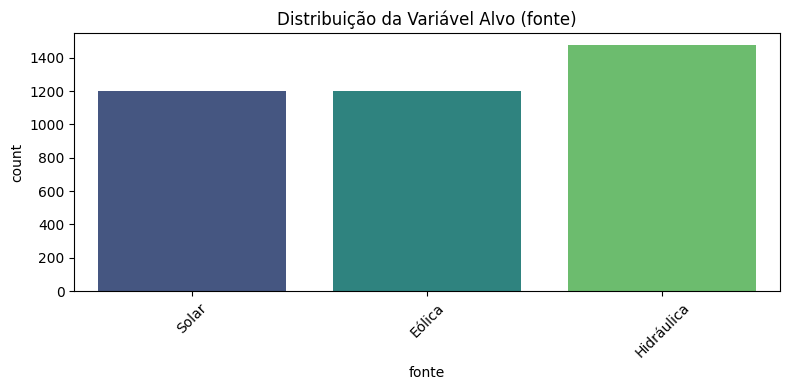

In [15]:
plt.figure(figsize=(8, 4))
sns.countplot(data=dados, x='fonte', hue='fonte', palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo (fonte)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Verificando se existem valores ausentes
valores_ausentes = dados.isnull().sum()
print("Valores ausentes por coluna:")
print(valores_ausentes[valores_ausentes > 0] if (valores_ausentes > 0).any() else "Nenhum valor ausente encontrado.")

Valores ausentes por coluna:
Nenhum valor ausente encontrado.


In [17]:
# Estatisticas Descritivas
dados.describe(include='object')

,fonte
count,3876
unique,3
top,Hidráulica
freq,1476




---



###Definir X e y

In [18]:
X = dados.drop('fonte', axis=1)
y = dados['fonte']

In [19]:
X

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000
...,...,...,...
3871,2000.00,0.000000,0.000000
3872,1500.00,0.000000,0.000000
3873,710.00,0.000000,0.000000
3874,297.50,0.000000,0.000000


In [20]:
y

,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar
...,...
3871,Hidráulica
3872,Hidráulica
3873,Hidráulica
3874,Hidráulica


## 1_2 Divisão Estratificada

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Ajuste da escala treinado somente com o conjunto de treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verificar os tamanhos dos conjuntos
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras\n")

# Confirmar a proporção da divisão estratificada em %
print("--- Proporção das classes no Treino (%) ---")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\n--- Proporção das classes no Teste (%) ---")
print((y_test.value_counts(normalize=True) * 100).round(2))



Treino: 3100 amostras
Teste:  776 amostras

--- Proporção das classes no Treino (%) ---
fonte
Hidráulica    38.06
Solar         30.97
Eólica        30.97
Name: proportion, dtype: float64

--- Proporção das classes no Teste (%) ---
fonte
Hidráulica    38.14
Solar         30.93
Eólica        30.93
Name: proportion, dtype: float64


## 1_3 Treino dos 3 Classificadores Diferentes

In [22]:
# Instanciar os classificadores
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Treinar todos os modelos nos dados de treino escalados
for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    print(f"✅ {nome} treinado com sucesso!")


✅ Regressão Logística treinado com sucesso!
✅ Árvore de Decisão treinado com sucesso!
✅ Random Forest treinado com sucesso!


## 1_4 Avaliação das Métricas e Matriz de Confusão

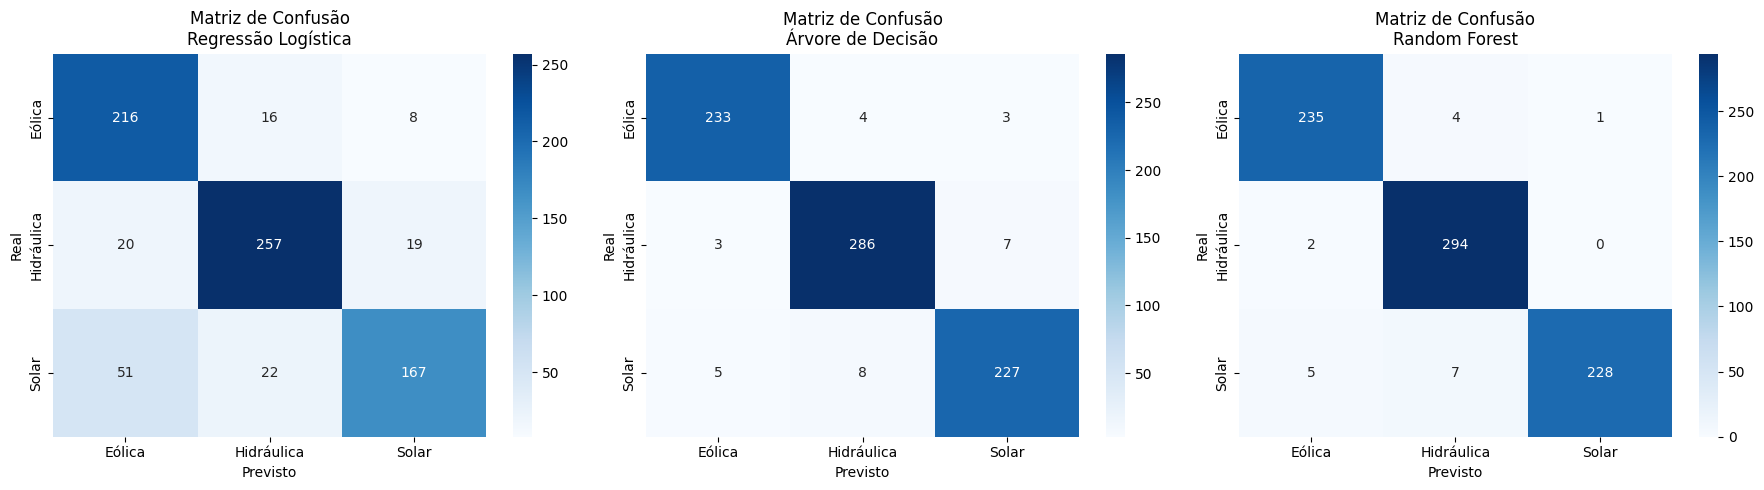


=== TABELA COMPARATIVA DOS TRÊS ALGORITMOS ===
          Algoritmo  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
Regressão Logística    0.8247             0.8282          0.8214            0.8197
  Árvore de Decisão    0.9613             0.9614          0.9610            0.9612
      Random Forest    0.9755             0.9769          0.9741            0.9753


In [23]:
resultados = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nome_modelo, modelo) in enumerate(modelos.items()):
    # Treinamento
    modelo.fit(X_train_scaled, y_train)

    # Previsões
    y_pred = modelo.predict(X_test_scaled)

    # Cálculo das métricas por classe com média 'macro'
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    resultados.append({
        "Algoritmo": nome_modelo,
        "Accuracy": round(acc, 4),
        "Precision (macro)": round(prec, 4),
        "Recall (macro)": round(rec, 4),
        "F1-Score (macro)": round(f1, 4)
    })

    # Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=np.unique(y), yticklabels=np.unique(y)
    )
    axes[idx].set_title(f'Matriz de Confusão\n{nome_modelo}')
    axes[idx].set_xlabel('Previsto')
    axes[idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Apresentação da Tabela Comparativa de Resultados
df_resultados = pd.DataFrame(resultados)
print("\n=== TABELA COMPARATIVA DOS TRÊS ALGORITMOS ===")
print(df_resultados.to_string(index=False))

## 1_5 Análise dos resultados e Conclusão

1 - O modelo escolhido para esta aplicação é o Random Forest.  Apresentou o melhor desempenho geral entre todos os testados, alcançando Accuracy de 97,55% e F1-Score (macro) de 0,9753. Por ser um método de ensemble (combinação de várias árvores de decisão), o Random Forest possui maior capacidade de generalização, lida melhor com relações não lineares nos dados e reduz o risco de overfitting em comparação com uma árvore de decisão simples.   

2 - Classe mais confundida: A classe Solar apresentou a maior taxa de erro de classificação. De um total de 240 usinas solares no teste, 7 foram classificadas incorretamente como Hidráulica e 5 foram classificadas como Eólica (12 erros no total).   Outras classes: A classe Hidráulica teve apenas 2 erros (confundida com Eólica) e a classe Eólica teve 5 erros (4 confundidas com Hidráulica e 1 com Solar).    

3 - Limitações de Potência e Localização em Aplicações de Atributos (Overlapping): Usinas de fontes diferentes (como parques eólicos e complexos solares) podem ser projetadas para fornecer a mesma potência instalada (kW) em uma determinada região, o que impede a diferenciação baseada apenas na capacidade de geração.   Vazamento Espacial / Correlação Espúria (Data Leakage): Coordenadas geográficas (latitude e longitude) indicam onde a infraestrutura foi instalada, mas não o princípio físico de funcionamento da usina. Usar localização pode fazer o modelo memorizar regiões específicas em vez de aprender as características intrínsecas do tipo de geração.   Falha na Generalização: Se uma nova usina solar for instalada próxima a um parque eólico já existente, um modelo dependente de coordenadas geográficas falhará ao classificar a nova instalação. Em ambiente de produção, é indispensável utilizar variáveis físicas e operacionais contínuas para garantir predições confiáveis.



---



# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [24]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [25]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [26]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [27]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## 1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina X (cinco entradas) e y (radiacao_w_m2).

In [28]:
# Carregar CSV
dados = pd.read_csv('meteo_regressao_orange.csv')
dados['data_hora'] = pd.to_datetime(dados['data_hora'])

In [29]:
#Tabela
dados.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0


In [30]:
dados.shape[0]

1001

In [31]:
# Nomes e tipos de colunas
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data_hora      1001 non-null   datetime64[ns]
 1   temperatura_c  1001 non-null   float64       
 2   umidade_pct    1001 non-null   int64         
 3   nuvens_pct     1001 non-null   int64         
 4   vento_kmh      1001 non-null   float64       
 5   hora           1001 non-null   int64         
 6   radiacao_w_m2  1001 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 54.9 KB


In [32]:
#Valores de ausência
valores_ausentes = dados.isnull().sum()
print("Valores ausentes por coluna:")
print(valores_ausentes[valores_ausentes > 0] if (valores_ausentes > 0).any() else "Nenhum valor ausente encontrado.")

Valores ausentes por coluna:
Nenhum valor ausente encontrado.


In [33]:
#Menos uma visualização
print(dados['data_hora'].min(), '->', dados['data_hora'].max())

2025-04-01 07:00:00 -> 2025-06-30 17:00:00


In [34]:
#Devinindo X e Y
X = dados.drop(['data_hora', 'radiacao_w_m2'],axis=1)
y = dados['radiacao_w_m2']

X.head()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11


## 2. Mantenha as linhas em ordem de data_hora: use aproximadamente 80% das primeiras horas para treino e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.

In [35]:
dados['data_hora']= pd.to_datetime(dados['data_hora'])
dados =  dados.sort_values('data_hora'). reset_index(drop=True)

In [36]:
#Divisão
ponto=int(len(dados)*0.8)
x_treino = X.iloc[:ponto]
x_teste = X.iloc[ponto:]

y_treino = y.iloc[:ponto]
y_teste = y.iloc[ponto:]

print("Treino:", len(x_treino))
print("Teste:", len(x_teste))

Treino: 800
Teste: 201


## 3.Escolha, justifique e treine três algoritmos de regressão diferentes com a mesma divisão. Os imports e a implementação são sua responsabilidade.

In [37]:
#Três modelos
modelo_linear = LinearRegression()
modelo_arvore = DecisionTreeRegressor(random_state=42)
modelo_rf = RandomForestRegressor( n_estimators=100, random_state=42)

In [38]:
#Treinar
modelo_linear.fit(x_treino, y_treino)
modelo_arvore.fit(x_treino, y_treino)
modelo_rf.fit(x_treino, y_treino)
print("Os três modelos foram treinados com sucesso!")

Os três modelos foram treinados com sucesso!


In [39]:
#Previsão
previsao_linear = modelo_linear.predict(x_teste)
previsao_arvore = modelo_arvore.predict(x_teste)
previsao_rf = modelo_rf.predict(x_teste)

## 4. Compare MAE (W/m²), MSE ((W/m²)²) e R²; faça um gráfico de valores reais × previstos de pelo menos um modelo.

In [40]:
#Regressão linear
r2_modelo_1 = r2_score(y_teste, previsao_linear)
mae_modelo_1 = mean_absolute_error(y_teste, previsao_linear)
mse_modelo_1 = mean_squared_error(y_teste, previsao_linear)

print(f"Modelo 1 - R²: {r2_modelo_1:.4f}")
print(f"Modelo 1 - MAE: {mae_modelo_1:.4f} W/m²")
print(f"Modelo 1 - MSE: {mse_modelo_1:.4f} (W/m²)²")

Modelo 1 - R²: 0.3598
Modelo 1 - MAE: 145.2049 W/m²
Modelo 1 - MSE: 30034.2011 (W/m²)²


In [41]:
#Árvore de decisão
r2_modelo_2 = r2_score(y_teste, previsao_arvore)
mae_modelo_2 = mean_absolute_error(y_teste, previsao_arvore)
mse_modelo_2 = mean_squared_error(y_teste, previsao_arvore)

print(f"\nModelo 2 - R²: {r2_modelo_2:.4f}")
print(f"Modelo 2 - MAE: {mae_modelo_2:.4f} W/m²")
print(f"Modelo 2 - MSE: {mse_modelo_2:.4f} (W/m²)²")


Modelo 2 - R²: 0.6741
Modelo 2 - MAE: 88.7910 W/m²
Modelo 2 - MSE: 15291.1592 (W/m²)²


In [42]:
#Random Forest
r2_modelo_3 = r2_score(y_teste, previsao_rf)
mae_modelo_3 = mean_absolute_error(y_teste, previsao_rf)
mse_modelo_3 = mean_squared_error(y_teste, previsao_rf)

print(f"\nModelo 3 - R²: {r2_modelo_3:.4f}")
print(f"Modelo 3 - MAE: {mae_modelo_3:.4f} W/m²")
print(f"Modelo 3 - MSE: {mse_modelo_3:.4f} (W/m²)²")


Modelo 3 - R²: 0.8442
Modelo 3 - MAE: 66.8042 W/m²
Modelo 3 - MSE: 7307.4179 (W/m²)²


In [43]:
comparacao_modelos = pd.DataFrame({'Modelo': ['Regressão Linear','Árvore de Decisão', 'Random Forest'],
    'Variáveis utilizadas': ['5 entradas','5 entradas','5 entradas'],
    'R²': [r2_modelo_1,r2_modelo_2, r2_modelo_3],
    'MAE (W/m²)': [ mae_modelo_1,mae_modelo_2, mae_modelo_3],
    'MSE ((W/m²)²)': [ mse_modelo_1,mse_modelo_2,mse_modelo_3 ]})

display(comparacao_modelos)

,Modelo,Variáveis utilizadas,R²,MAE (W/m²),MSE ((W/m²)²)
0,Regressão Linear,5 entradas,0.359845,145.204885,30034.201092
1,Árvore de Decisão,5 entradas,0.674081,88.791045,15291.159204
2,Random Forest,5 entradas,0.844248,66.804179,7307.417901


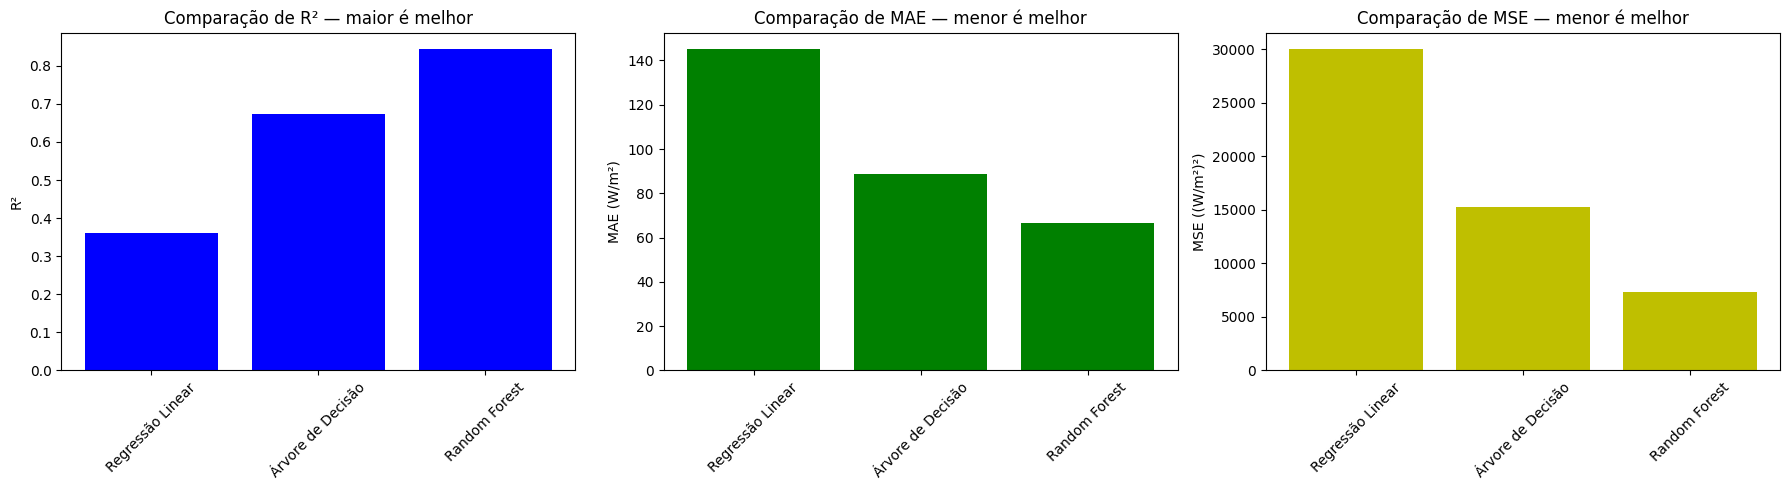

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R²
axes[0].bar(comparacao_modelos['Modelo'],comparacao_modelos['R²'],color='blue')
axes[0].set_title('Comparação de R² — maior é melhor')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=45)

# MAE
axes[1].bar(comparacao_modelos['Modelo'],comparacao_modelos['MAE (W/m²)'],color='g')
axes[1].set_title('Comparação de MAE — menor é melhor')
axes[1].set_ylabel('MAE (W/m²)')
axes[1].tick_params(axis='x', rotation=45)

# MSE
axes[2].bar(comparacao_modelos['Modelo'],comparacao_modelos['MSE ((W/m²)²)'],color='y')
axes[2].set_title('Comparação de MSE — menor é melhor')
axes[2].set_ylabel('MSE ((W/m²)²)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação não prevê automaticamente a energia produzida por um sistema fotovoltaico.

A hora do dia influencia bastante a radiação, pois ela varia conforme a posição do Sol. Os erros mostram que apenas a hora não consegue representar fatores como nuvens, chuva, temperatura e condições atmosféricas.

Além disso, radiação solar não é igual à energia produzida. A geração depende também da potência e eficiência dos painéis, orientação, temperatura, sombreamento e perdas do sistema. Portanto, para prever a energia fotovoltaica, é necessário combinar a radiação com as características do sistema.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)